In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import  GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Set plot style
plt.style.use('default')
sns.set_theme()

In [4]:
train_data = pd.read_csv('archive/train.csv')
val_data = pd.read_csv('archive/validation.csv')
test_data = pd.read_csv('archive/test.csv')


In [5]:
features = ['SchoolType', 'Locale', 'InternetAccess', 'SES_Quartile', 
           'ParentalEducation', 'Romantic', 'Extracurricular', 'ParentSupport']
targets = ['TestScore_Math', 'TestScore_Reading', 'TestScore_Science', 'GPA']


In [6]:
le_dict = {}
X_train = pd.DataFrame()
X_val = pd.DataFrame()
X_test = pd.DataFrame()

for feature in features:
    le = LabelEncoder()
    le_dict[feature] = le
    X_train[feature] = le.fit_transform(train_data[feature])
    X_val[feature] = le.transform(val_data[feature])
    X_test[feature] = le.transform(test_data[feature])

In [7]:
y_train = train_data[targets]
y_val = val_data[targets]
y_test = test_data[targets]

In [8]:
# Initialize models for each target
models = {}
predictions = {}

# Hyperparameter tuning
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

for target in targets:
    print(f"\nTraining model for {target}")
    
    # Initialize and train model
    model = DecisionTreeRegressor(random_state=42)
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
    grid_search.fit(X_train, y_train[target])
    
    # Get best model
    models[target] = grid_search.best_estimator_
    
    # Make predictions
    predictions[target] = {
        'train': models[target].predict(X_train),
        'val': models[target].predict(X_val),
        'test': models[target].predict(X_test)
    }
    
    print(f"Best parameters for {target}:", grid_search.best_params_)


Training model for TestScore_Math
Best parameters for TestScore_Math: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Training model for TestScore_Reading
Best parameters for TestScore_Reading: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Training model for TestScore_Science
Best parameters for TestScore_Science: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Training model for GPA
Best parameters for GPA: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [9]:
def evaluate_model(y_true, y_pred, dataset_name, target):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\nPerformance for {target} on {dataset_name} dataset:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

# Evaluate each model
for target in targets:
    print(f"\n=== Evaluation for {target} ===")
    evaluate_model(y_train[target], predictions[target]['train'], "Training", target)
    evaluate_model(y_val[target], predictions[target]['val'], "Validation", target)
    evaluate_model(y_test[target], predictions[target]['test'], "Test", target)


=== Evaluation for TestScore_Math ===

Performance for TestScore_Math on Training dataset:
MSE: 98.9014
RMSE: 9.9449
R² Score: 0.0000

Performance for TestScore_Math on Validation dataset:
MSE: 99.0731
RMSE: 9.9535
R² Score: -0.0000

Performance for TestScore_Math on Test dataset:
MSE: 98.8902
RMSE: 9.9444
R² Score: -0.0000

=== Evaluation for TestScore_Reading ===

Performance for TestScore_Reading on Training dataset:
MSE: 98.8691
RMSE: 9.9433
R² Score: 0.0000

Performance for TestScore_Reading on Validation dataset:
MSE: 98.8609
RMSE: 9.9429
R² Score: -0.0000

Performance for TestScore_Reading on Test dataset:
MSE: 99.0946
RMSE: 9.9546
R² Score: -0.0000

=== Evaluation for TestScore_Science ===

Performance for TestScore_Science on Training dataset:
MSE: 98.9733
RMSE: 9.9485
R² Score: 0.0000

Performance for TestScore_Science on Validation dataset:
MSE: 99.0487
RMSE: 9.9523
R² Score: -0.0000

Performance for TestScore_Science on Test dataset:
MSE: 98.9288
RMSE: 9.9463
R² Score: -0.

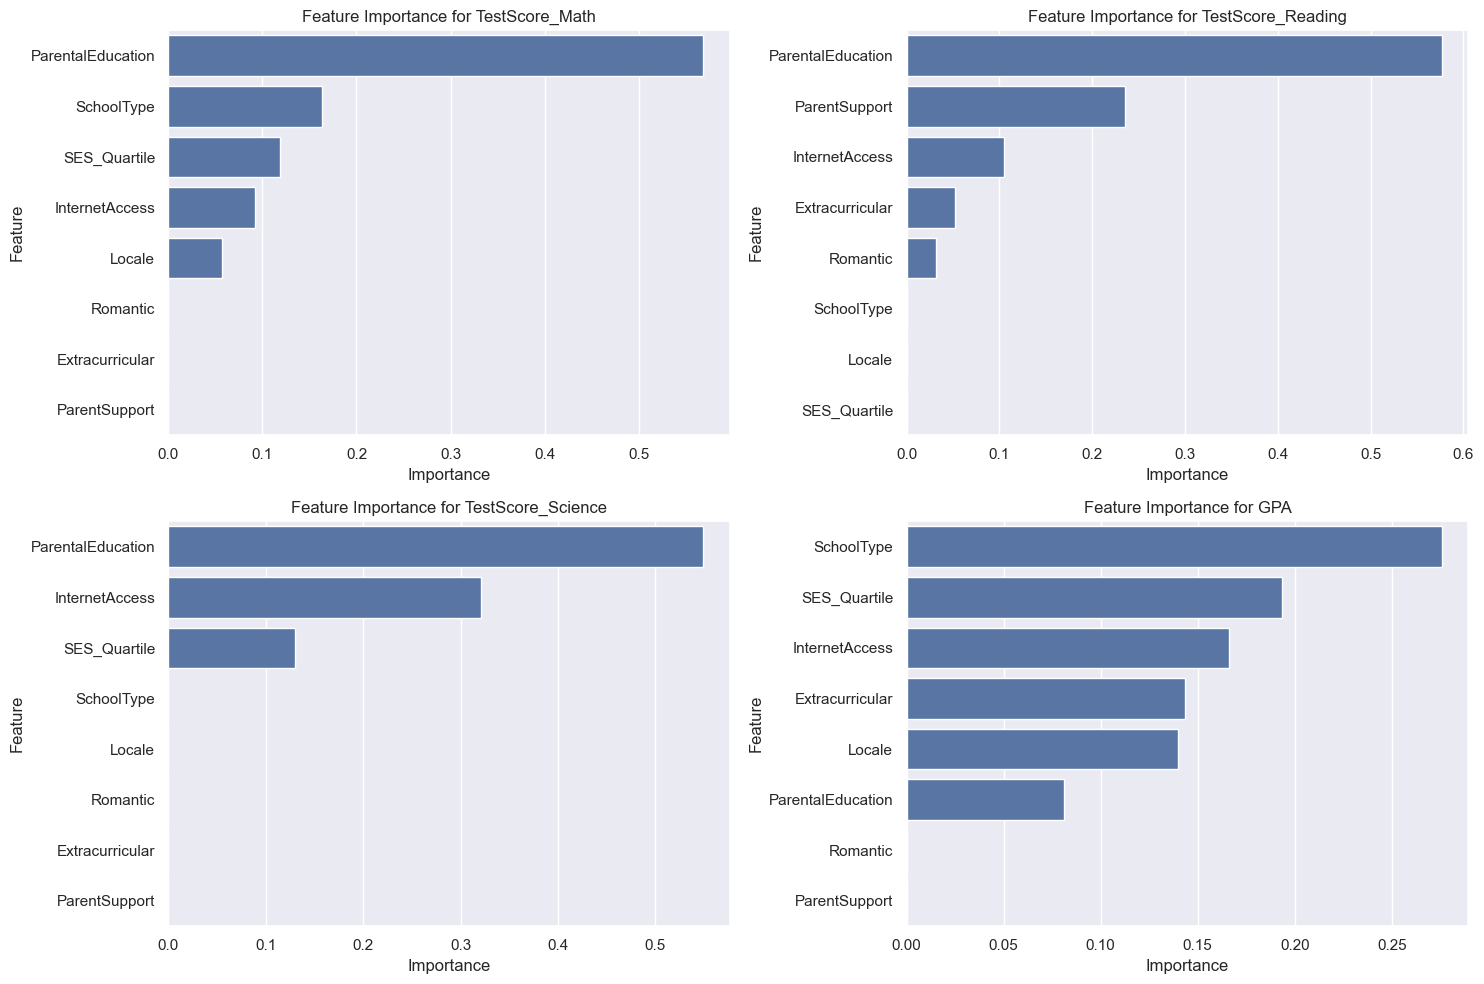

In [10]:
# Plot feature importance for each target
plt.figure(figsize=(15, 10))
for i, target in enumerate(targets):
    plt.subplot(2, 2, i+1)
    importance = pd.DataFrame({
        'Feature': features,
        'Importance': models[target].feature_importances_
    })
    importance = importance.sort_values('Importance', ascending=False)
    
    sns.barplot(x='Importance', y='Feature', data=importance)
    plt.title(f'Feature Importance for {target}')
    plt.tight_layout()
plt.show()

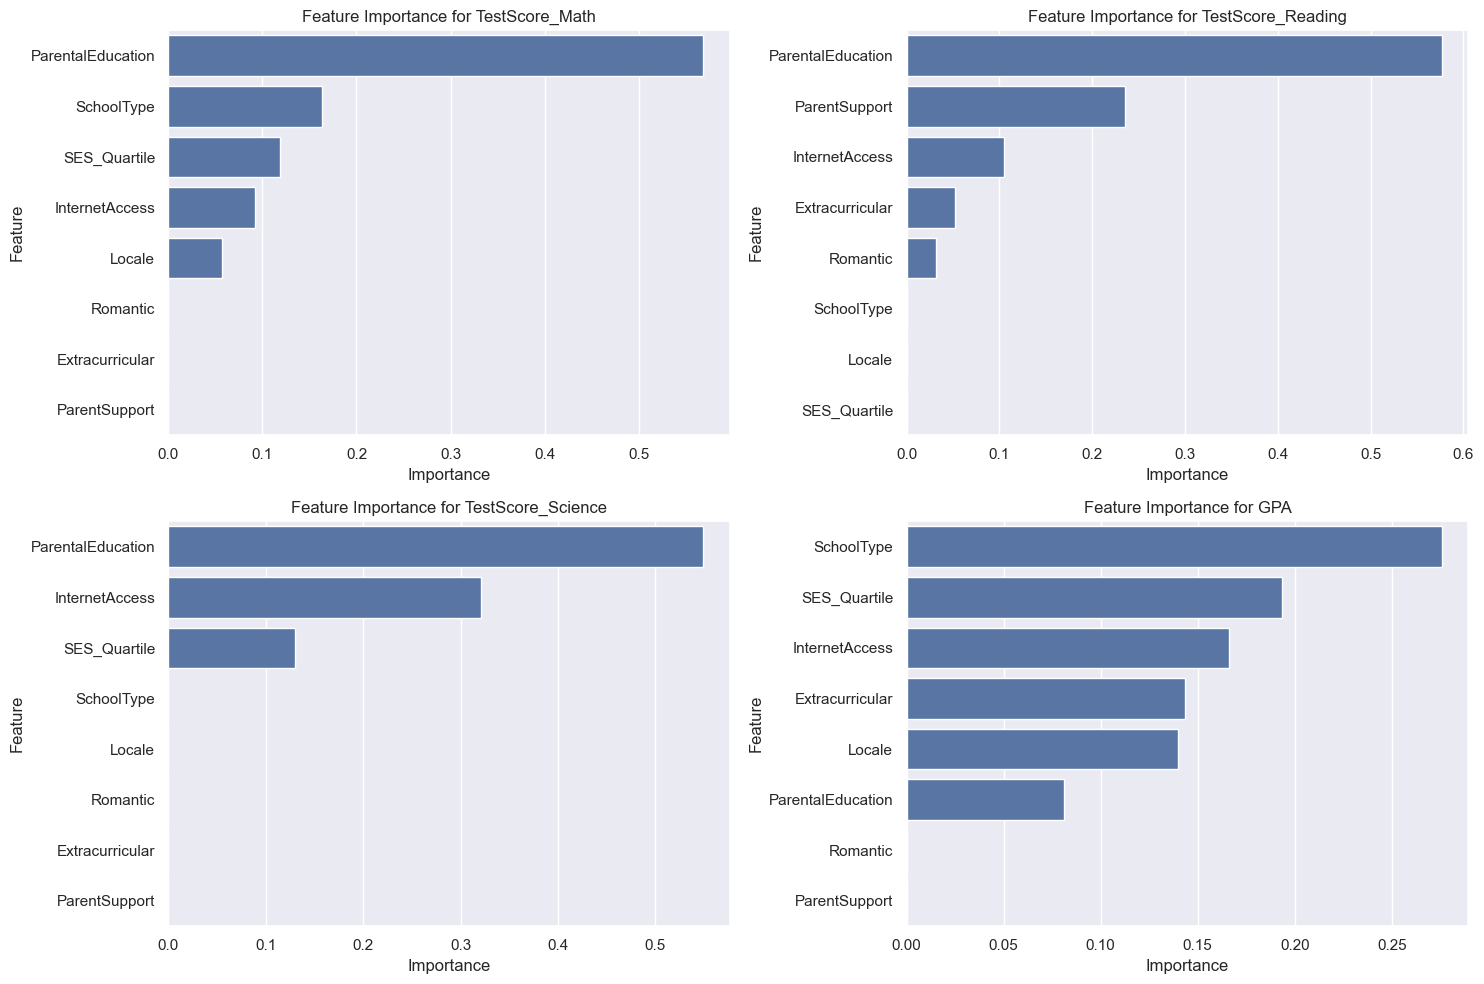

In [11]:
# Plot feature importance for each target
plt.figure(figsize=(15, 10))
for i, target in enumerate(targets):
    plt.subplot(2, 2, i+1)
    importance = pd.DataFrame({
        'Feature': features,
        'Importance': models[target].feature_importances_
    })
    importance = importance.sort_values('Importance', ascending=False)
    
    sns.barplot(x='Importance', y='Feature', data=importance)
    plt.title(f'Feature Importance for {target}')
    plt.tight_layout()
plt.show()

In [12]:
# Save results
results = {
    'model_params': {target: model.get_params() for target, model in models.items()},
    'feature_importance': {
        target: dict(zip(features, model.feature_importances_))
        for target, model in models.items()
    },
    'performance': {
        target: {
            'train': {
                'mse': mean_squared_error(y_train[target], predictions[target]['train']),
                'rmse': np.sqrt(mean_squared_error(y_train[target], predictions[target]['train'])),
                'r2': r2_score(y_train[target], predictions[target]['train'])
            },
            'validation': {
                'mse': mean_squared_error(y_val[target], predictions[target]['val']),
                'rmse': np.sqrt(mean_squared_error(y_val[target], predictions[target]['val'])),
                'r2': r2_score(y_val[target], predictions[target]['val'])
            },
            'test': {
                'mse': mean_squared_error(y_test[target], predictions[target]['test']),
                'rmse': np.sqrt(mean_squared_error(y_test[target], predictions[target]['test'])),
                'r2': r2_score(y_test[target], predictions[target]['test'])
            }
        }
        for target in targets
    }
}

# Save feature importance to CSV
for target in targets:
    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': models[target].feature_importances_
    })
    importance_df = importance_df.sort_values('Importance', ascending=False)
    importance_df.to_csv(f'feature_importance_{target}.csv', index=False)